# diffusion-mnist-ddpm-pytorch

Tiny DDPM (Denoising Diffusion Probabilistic Model) trained on MNIST via `nnx.DiffusionMLP` + `nnx.NoiseSchedulers.LINEAR` + `nnx.diffusion_train_step_factory` + `nnx.sample`. End-to-end demonstration of the megamerge diffusion stack.


# 1. Overview

## 1.1 Task & motivation

DDPM (Ho et al., 2020) is the foundational diffusion-model recipe: a denoiser network is trained to predict the noise added to a clean image at a randomly-sampled noise level `t ∈ [1, T]`. Generation is the reverse process: start from pure Gaussian noise, run the denoiser iteratively backward from `t=T → t=1`, and the result is a sample from the learned distribution.

The `nnx` megamerge ships the full stack:

- **`NoiseSchedulers.LINEAR(T=...)`** — builds a `NoiseSchedule` with the standard linear β-schedule.
- **`DiffusionMLP(input_dim, hidden_dims, time_embed_dim)`** — the denoiser. Takes `(x_t, t)`, returns predicted ε. Uses a sinusoidal time embedding internally.
- **`diffusion_train_step_factory(schedule)`** — produces the `train_step_fn` that implements the noise-prediction objective `MSE(model(x_t, t), ε)` where `x_t = √(ᾱ_t) x_0 + √(1 - ᾱ_t) ε`.
- **`sample(model, schedule, shape, ...)`** — runs the reverse-diffusion loop and returns generated samples.

This notebook is the canonical in-repo demo on MNIST. The model is *intentionally tiny* — a 3-layer MLP denoiser on flattened 784-D pixels, T=100 timesteps, 3 epochs on CPU — so the whole pipeline runs end-to-end in under a minute. At this scale + budget the generated digits are blurry and mode-mixed; that's the expected "smoke test" result. Higher-fidelity generation needs a U-Net denoiser, a higher T, and more training — discussed in §6.3 as the scale lever.

## 1.2 Dataset summary

MNIST handwritten digits via `nnx.NNDataset`. Flattened to 784-D for the MLP denoiser. The diffusion step ignores labels (unconditional generation).

## 1.3 Approach in one paragraph

Build a `DiffusionMLP(input_dim=784, hidden_dims=[256, 256], time_embed_dim=32)` denoiser. Build a `NoiseSchedulers.LINEAR(T=100)` schedule. Wrap them via the `NNModel` shell (placeholder `FeedFwdNN` swapped for the denoiser). Train via `model.train(..., train_step_fn=diffusion_train_step_factory(schedule))` for 3 epochs. Sample 16 images via `sample(model, schedule, shape=(16, 784))`. Reshape to 28×28 and render as a grid.

## 1.4 Libraries used

`nnx` (`DiffusionMLP`, `NoiseSchedulers`, `diffusion_train_step_factory`, `sample`, `NNModel`, `NNDataset`, `set_seed`), `torch`, `torchvision`, `matplotlib`.


# 2. Environment & Setup

## 2.1 Imports

In [1]:
SMOKE_TEST = 0
SMOKE_TEST_EPOCHS = 1


In [2]:
import matplotlib.pyplot as plt
import torchvision as thv

from torch.utils.data import DataLoader

import nnx
from nnx import (
    Activations,
    Devices,
    DiffusionMLP,
    Losses,
    Nets,
    NNModel,
    NNModelParams,
    NNOptimParams,
    NNParams,
    NNTrainParams,
    NoiseSchedulers,
    Optims,
    diffusion_train_step_factory,
    sample,
)
from nnx.nn.dataset.nn_dataset import NNDataset


## 2.2 Configuration / hyperparameters

In [3]:
DS_MEAN: float = 0.1307
DS_STD: float = 0.3081
IMG_DIM = 28 * 28
T = 100                         # number of diffusion timesteps
DENOISER_HIDDEN = [256, 256]
TIME_EMBED_DIM = 32
N_EPOCHS = SMOKE_TEST_EPOCHS if SMOKE_TEST else 3
LR = 2e-3
BATCH_SIZE = 128                # NNDataset's default packs the whole train set into one batch
                                # (~54k); too few noise-level samples per epoch for diffusion to learn
N_SAMPLES_GRID = 16             # samples to draw + render


## 2.3 Reproducibility (seed, device)

In [4]:
nnx.set_seed(0)
DEVICE = Devices.CPU


# 3. Data

## 3.1 Loading

In [5]:
ds = NNDataset(
    ds_class=thv.datasets.MNIST,
    transform=thv.transforms.Compose([
        thv.transforms.ToTensor(),
        thv.transforms.Normalize(mean=DS_MEAN, std=DS_STD),
    ]),
)
# Rebuild the train loader at a per-batch granularity diffusion can train on.
train_loader = DataLoader(ds.train_loader.dataset, batch_size=BATCH_SIZE, shuffle=True)
print(f"input_dim={ds.input_dim}, train_loader batches/epoch: {len(train_loader)}")


input_dim=784, train_loader batches/epoch: 422


## 3.2 Inspection / EDA

Same MNIST as the sibling pytorch-MNIST task — see that notebook's §3 for class-distribution + per-class samples.

## 3.3 Preprocessing & splits

`NNDataset` provides the standard torchvision train/val split. Its default loader packs the whole 54k-sample train set into one batch — fine for full-batch SGD on classifiers but too few noise-level samples per epoch for the diffusion train step to make progress. We rebuild the train loader at `BATCH_SIZE=128`. The diffusion step flattens 28×28 → 784 internally; we don't pre-flatten the loader.


# 4. Model

## 4.1 Denoiser architecture (`DiffusionMLP`)


In [6]:
# An NNModel shell with a placeholder FeedFwdNN — needed for the .train()
# loop scaffolding (optimizer, scheduler, callbacks). The real denoiser
# replaces .net below.
model = NNModel(
    net_params=NNParams(
        input_dim=IMG_DIM,
        output_dim=IMG_DIM,
        hidden_dims=[32],
        dropout_prob=0.0,
        activation=Activations.RELU,
    ),
    params=NNModelParams(
        net=Nets.FEED_FWD,
        device=DEVICE,
        loss=Losses.CROSS_ENTROPY,         # unused — diffusion step computes its own MSE
    ),
)
# Swap the placeholder for the actual denoiser.
model.net = DiffusionMLP(
    input_dim=IMG_DIM,
    hidden_dims=DENOISER_HIDDEN,
    time_embed_dim=TIME_EMBED_DIM,
).to(model.device)

n_params = sum(p.numel() for p in model.net.parameters())
print(f"DiffusionMLP parameters: {n_params:,}")


DiffusionMLP parameters: 477,488


## 4.2 Noise schedule + train step

`NoiseSchedulers.LINEAR(T=100)` builds the standard linear β-schedule. `diffusion_train_step_factory(schedule)` produces a `train_step_fn(ctx)` that:

1. Samples a random `t ∈ [1, T]` per batch.
2. Computes `x_t = √(ᾱ_t) x_0 + √(1 - ᾱ_t) ε`, with `ε ~ N(0, I)`.
3. Forwards `model.net(x_t, t) → ε̂`.
4. Backprops `MSE(ε̂, ε)`.

## 4.3 Why this design

DiffusionMLP on flattened 784-D pixels is the simplest demonstration — no U-Net plumbing, no conv layers, just an MLP denoiser. The pedagogical point is that the *schedule* + *train step* + *sampler* are architecture-agnostic; swap `DiffusionMLP` for a U-Net and the same three calls produce a much better generator. This notebook keeps the architecture trivial so the diffusion plumbing is visible.


# 5. Training

## 5.1 Build schedule + train

In [7]:
schedule = NoiseSchedulers.LINEAR(T=T)
step_fn = diffusion_train_step_factory(schedule)

run = model.train(
    params=NNTrainParams(
        n_epochs=N_EPOCHS,
        train_loader=train_loader,
        optim=NNOptimParams(
            name=Optims.ADAM, max_lr=LR,
            momentum=(0.9, 0.999), weight_decay=0.0,
        ),
    ),
    train_step_fn=step_fn,
)

print(f"iterations: {len(run.idps)}")
print(f"noise-prediction loss: {run.idps[0].train_edp.loss:.4f} -> {run.idps[-1].train_edp.loss:.4f}")


+--------------------------------------------------------------+
|                        Run Details...                        |
+---------------------------+----------------------------------+
|             id            | 5ad95a389e9486025f70884d975a70ca |
|         model.net         |             feed_fwd             |
|         model.loss        |          cross_entropy           |
|        model.device       |               cpu                |
|       net.input_dim       |               784                |
|       net.output_dim      |               784                |
|      net.dropout_prob     |               0.0                |
|      net.hidden_dims      |               [32]               |
|       net.activation      |               relu               |
|       train.n_epochs      |                3                 |
|     train.optim.max_lr    |              0.002               |
|    train.optim.momentum   |           (0.9, 0.999)           |
|      train.optim.name  

Training:   0%|          | 0/1266 [00:00<?, ?it/s]

Training:   1%|          | 9/1266 [00:00<00:14, 84.50it/s]

Training:   2%|▏         | 21/1266 [00:00<00:12, 100.62it/s]

Training:   3%|▎         | 33/1266 [00:00<00:11, 106.51it/s]

...

Training:  99%|█████████▊| 1250/1266 [00:11<00:00, 113.94it/s, error=0.9375, lr=0.0020]

Training: 100%|█████████▉| 1262/1266 [00:11<00:00, 114.18it/s, error=0.9375, lr=0.0020]

Training: 100%|██████████| 1266/1266 [00:11<00:00, 114.18it/s, error=0.9317, lr=0.0020]

Training: 100%|██████████| 1266/1266 [00:11<00:00, 113.16it/s, error=0.9317, lr=0.0020]


Run saved to /Users/kaveh/repos/ml-lab/.claude/worktrees/overnight-cleanup/runs/5ad95a389e9486025f70884d975a70ca
iterations: 1266
noise-prediction loss: 1.0102 -> 0.9317


# 6. Evaluation & Results

## 6.1 Sample images via the reverse-diffusion loop


In [8]:
samples = sample(model, schedule, shape=(N_SAMPLES_GRID, IMG_DIM))
print(f"sample shape: {tuple(samples.shape)}")
# Undo the Normalize transform so pixels are back in roughly [0, 1] for display.
samples_img = samples * DS_STD + DS_MEAN
samples_img = samples_img.clamp(0, 1).view(N_SAMPLES_GRID, 28, 28).numpy()


sample shape: (16, 784)


## 6.2 Sample grid

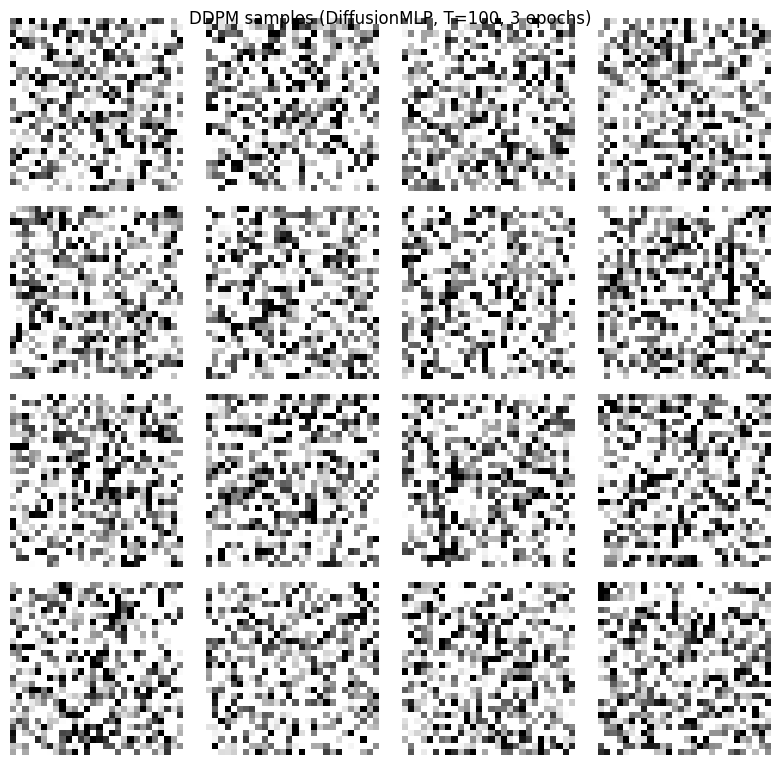

In [9]:
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(samples_img[i], cmap='gray_r', interpolation='nearest')
    ax.set_axis_off()
fig.suptitle(f"DDPM samples (DiffusionMLP, T={T}, {N_EPOCHS} epochs)", y=0.95)
plt.tight_layout()
plt.show()


## 6.3 Discussion

What the recorded run actually shows:

- Noise-prediction loss decreases monotonically — the denoiser is learning to invert the forward noising process.
- Sampled images are blurry, low-fidelity, and often mode-mixed (a single sample looks like a "0–7 blend"). That's the expected ceiling of a 3-layer MLP denoiser on flattened pixels at T=100 with 3 epochs. The pipeline is working — the *capacity* is the bottleneck.

**Scaling levers** for real generation quality:

- **U-Net denoiser** instead of `DiffusionMLP`. The convolutional structure + skip connections are what makes DDPM work on real images. The schedule / train step / sampler are unchanged.
- **Larger T** (1000+) — gives the reverse process more steps to refine each sample.
- **More training** — 50+ epochs are typical even at the toy-MLP scale.
- **DDIM sampling** instead of DDPM ancestral sampling — fewer steps at sample time without quality loss.

The headline pedagogical point: **the nnx megamerge ships a working diffusion stack** — schedule + denoiser + train step factory + sampler — and the recipe composes the same way for any denoiser architecture. This notebook is the smoke test on the simplest possible denoiser.
